# Meta-review Item 3 — initial alignment: chance level, not learned signal

**AC request:** *"Address initial alignment. Explain why some random initializations show high alignment and what this implies for the metric."* (raised by Reviewer UPiK: *"some random initializations show high alignment before any training ... if alignment can be near 1 at initialization then it's hard to see how it's measuring learned features."*)

**The two-part answer this notebook substantiates:**

1. **For the M3 network experiments (all 33 configs): initial alignment is exactly at the random-subspace chance level, never high.** For a uniformly random $r_t$-dim subspace vs a fixed $r_t$-dim teacher subspace in $\mathbb R^p$, $\mathbb E\bigl[\overline{\cos^2}\bigr] = r_t/p$ (from $\mathbb E\|Q_A^\top Q_B\|_F^2 = r_t^2/p$), and $\cos^2_{\min}$ concentrates far below that. We (a) derive/verify this null, (b) Monte-Carlo the null under the paper's *actual* init procedure (Gaussian init with in-$V$-mass rejection at 0.30, AGOP top-$r_t$ eigvectors), and (c) show every one of the 33 configs sits on the null: $\overline{\cos^2}(0) \approx r_t/p \in [0.04, 0.20]$ and $\cos^2_{\min}(0) \le 0.01$ (each value inside its null 99% band).

2. **The near-1 initial alignment the reviewer saw is the M2 toy figure — and those initializations are deterministic constructions, not random.** Theorem M2 is a *conditional* result whose hypothesis (H) requires a phase-selected initialization; the figure demonstrates the theorem under its own hypothesis: $y_0 = (k+\tfrac12)\eta$ in the leading mode, $c_{\rm off}\eta$ in off-modes, giving align(0) = 0.999 / 0.921 / 0.503 in panels (a)/(b)/(c) **by construction**. We compute these exactly and show they sit far outside the random-init null for $p = 8$ (mean $1/8$). The caption should state this loudly; we draft the fix.

**Implication for the metric:** since $\cos^2_{\min}(0)$ is at chance ($\le 0.01$) in every network experiment, the observed growth to $0.85$–$0.99$ during training is learned signal $\sim\!200\times$ above the null — the metric is measuring learned features.

**Runtime:** minutes on any CPU. No training runs.

## 0. Setup

In [1]:
import sys, math, csv, json, datetime, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

WORKDIR = Path('.').resolve()
sys.path.insert(0, str(WORKDIR / 'shared'))
from teacher_activation_sweep import make_problem, init_W
from teacher_full_runner import alignment_metrics

OUT = WORKDIR / 'item3_init_alignment'
OUT.mkdir(exist_ok=True)

REPS = 200          # Monte-Carlo repetitions per (p, r_t, r_s) combo
RNG  = np.random.default_rng(0)
print('Output dir:', OUT, '| MC reps:', REPS)

Output dir: /u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/item3_init_alignment | MC reps: 200


## 1. The analytic null and two Monte-Carlo nulls

**Analytic.** If $A$ is a uniformly random $r_t$-dim subspace and $B$ a fixed $r_t$-dim subspace of $\mathbb R^p$, with principal cosines $\cos\theta_i = \sigma_i(Q_A^\top Q_B)$, then $\mathbb E\sum_i \cos^2\theta_i = \mathbb E\|Q_A^\top Q_B\|_F^2 = r_t \cdot \frac{r_t}{p}$, so $\mathbb E[\overline{\cos^2}] = r_t/p$. (Each column of $Q_B$ has expected squared projection $r_t/p$ onto a random $r_t$-dim subspace.)

**MC null #1 (uniform subspace):** $Q_A = \mathrm{qr}(\text{Gaussian } p \times r_t)$.

**MC null #2 (the paper's actual init):** draw $W_0$ via `init_W` (Gaussian $/\sqrt p$, resampled until weight in-$V$ mass $\le 0.30$ — this rejection essentially never binds since the typical in-$V$ mass is $\approx r_t/p \ll 0.30$), then compute the top-$r_t$ AGOP eigenvectors with the paper's own `alignment_metrics` code, i.e. exactly the quantity plotted in every figure. By rotational invariance of the Gaussian init this should match null #1; the MC verifies there is no hidden bias from the AGOP construction or the rejection step.

In [2]:
# The (p, r_t, r_s) combos of the 33-config grid, read from item1's notebook.
#
# SINGLE SOURCE OF TRUTH: item1_all33_seeds.ipynb's CONFIGS_33. Two earlier
# versions of this were wrong in different ways. A hardcoded list held the OLD
# 8-combo grid and silently omitted 7. Deriving it from item1_all33/per_run.csv
# was better but still data-driven: that CSV only contains configurations that
# have already been TRAINED, so the null quietly shrank to the trained subset
# with no warning. Reading the grid definition covers every configuration we
# intend to report, and flags the ones whose checkpoints do not exist yet.
import ast as _ast

_nb1 = WORKDIR / 'item1_all33_seeds.ipynb'
if _nb1.exists():
    _cells = json.loads(_nb1.read_text())['cells']
    _src = next(''.join(c['source']) for c in _cells
                if 'CONFIGS_33 = [' in ''.join(c['source']))
    _lit = _src[_src.index('CONFIGS_33 = ['):]
    _lit = _lit[_lit.index('['):_lit.index('\n]') + 2]
    _cfg = _ast.literal_eval(_lit)
    COMBOS = sorted({(p, rt, rs) for _, _, p, rt, rs, _, _ in _cfg})
    print(f'{len(COMBOS)} combos from CONFIGS_33 ({len(_cfg)} configurations)')
else:
    COMBOS = [(100, 4, 50), (100, 6, 50), (100, 8, 30), (100, 8, 50),
              (100, 8, 80), (100, 8, 100), (100, 10, 50), (100, 12, 50),
              (100, 12, 75), (100, 12, 80), (100, 16, 50), (100, 20, 50),
              (150, 8, 50), (200, 12, 50), (200, 12, 80)]
    print(f'{len(COMBOS)} combos (fallback -- item1 notebook not found)')

# Which combos have no trained checkpoints? The MC null needs no training, but
# the MEASURED column does, so say plainly which rows will come back empty.
_ck = WORKDIR / 'item1_all33'
_untrained = []
for _p, _rt, _rs in COMBOS:
    if not list(_ck.glob(f'*_p{_p}_rt{_rt}_rs{_rs}_n*.npz')):
        _untrained.append((_p, _rt, _rs))
for _p, _rt, _rs in COMBOS:
    _flag = '   <-- no checkpoints yet' if (_p, _rt, _rs) in _untrained else ''
    print(f'   p={_p:<4} r_t={_rt:<3} r_s={_rs:<4} chance r_t/p = {_rt/_p:.3f}{_flag}')
if _untrained:
    print(f'\nNOTE: {len(_untrained)} of {len(COMBOS)} combos have no item1 checkpoints. '
          f'Their NULL will still be computed (it needs no training), but the\n'
          f'      MEASURED column will be blank until those configurations run.')

def uniform_subspace_null(p, r_t, reps, rng):
    """cos2_min and mean_cos2 for uniformly random r_t-dim subspace pairs."""
    out = []
    for _ in range(reps):
        QA, _ = np.linalg.qr(rng.standard_normal((p, r_t)))
        QB, _ = np.linalg.qr(rng.standard_normal((p, r_t)))
        sv = np.clip(np.linalg.svd(QA.T @ QB, compute_uv=False), 0, 1)
        out.append((float(sv.min()**2), float((sv**2).mean())))
    return np.array(out)

def agop_init_null(p, r_t, r_s, reps, rng, n=15000):
    """cos2_min and mean_cos2 of the top-r_t AGOP eigvecs at the paper's
    ACTUAL initialization, using the paper's own metric code."""
    # One fixed problem instance (X, U_t); W_0 varies across reps.
    X, y, _, _, U_t, _ = make_problem(p, r_t, n, n_test=10, seed=123,
                                      teacher_act='relu')
    a_s = (1.0/math.sqrt(p)) * np.ones(r_s)
    P_V = U_t @ U_t.T
    out = []
    for _ in range(reps):
        W0, _ = init_W(p, r_s, U_t, rng=rng)
        am = alignment_metrics(W0, X, U_t, a_s, P_V)
        out.append((am['cos2_min_AGOP'], am['mean_cos2_AGOP']))
    return np.array(out)

nulls = {}
for (p, r_t, r_s) in COMBOS:
    u = uniform_subspace_null(p, r_t, REPS, RNG)
    a = agop_init_null(p, r_t, r_s, REPS, RNG)
    nulls[(p, r_t, r_s)] = dict(uniform=u, agop=a)
    print(f'p={p} r_t={r_t:>2d} r_s={r_s:>2d} | analytic mean = {r_t/p:.3f} | '
          f'uniform MC: mean_cos2 = {u[:,1].mean():.3f}, cos2_min 99% = {np.percentile(u[:,0],99):.4f} | '
          f'AGOP-init MC: mean_cos2 = {a[:,1].mean():.3f}, cos2_min 99% = {np.percentile(a[:,0],99):.4f}')

15 combos from CONFIGS_33 (33 configurations)
   p=100  r_t=4   r_s=50   chance r_t/p = 0.040
   p=100  r_t=6   r_s=50   chance r_t/p = 0.060
   p=100  r_t=8   r_s=30   chance r_t/p = 0.080
   p=100  r_t=8   r_s=50   chance r_t/p = 0.080
   p=100  r_t=8   r_s=80   chance r_t/p = 0.080
   p=100  r_t=8   r_s=100  chance r_t/p = 0.080
   p=100  r_t=10  r_s=50   chance r_t/p = 0.100
   p=100  r_t=12  r_s=50   chance r_t/p = 0.120
   p=100  r_t=12  r_s=75   chance r_t/p = 0.120
   p=100  r_t=12  r_s=80   chance r_t/p = 0.120
   p=100  r_t=16  r_s=50   chance r_t/p = 0.160
   p=100  r_t=20  r_s=50   chance r_t/p = 0.200
   p=150  r_t=8   r_s=50   chance r_t/p = 0.053
   p=200  r_t=12  r_s=50   chance r_t/p = 0.060
   p=200  r_t=12  r_s=80   chance r_t/p = 0.060
p=100 r_t= 4 r_s=50 | analytic mean = 0.040 | uniform MC: mean_cos2 = 0.039, cos2_min 99% = 0.0179 | AGOP-init MC: mean_cos2 = 0.041, cos2_min 99% = 0.0172
p=100 r_t= 6 r_s=50 | analytic mean = 0.060 | uniform MC: mean_cos2 = 0.060, c

## 2. Measured init alignment across all 33 configs vs the null

Reads $\cos^2_{\min}(0)$ and $\overline{\cos^2}(0)$ (the $t{=}0$ log entry — logged **before** the first update) from the checkpoints. Uses `item1_all33/` (5 seeds) if present, else falls back to the original single-seed grids in `../code_bundle/`.

In [3]:
def parse_meta(stem):
    parts = stem.split('_'); out = dict(teacher=parts[0], p=None, r_t=None, r_s=None)
    for tok in parts[1:]:
        if   tok.startswith('p')  and tok[1:].isdigit():  out['p']   = int(tok[1:])
        elif tok.startswith('rt'):
            try: out['r_t'] = int(tok[2:])
            except: pass
        elif tok.startswith('rs'):
            try: out['r_s'] = int(tok[2:])
            except: pass
    return out

src_dirs = []
if (WORKDIR/'item1_all33').exists() and list((WORKDIR/'item1_all33').glob('*.npz')):
    src_dirs = [WORKDIR/'item1_all33']
else:
    cb = WORKDIR.parent / 'code_bundle'
    src_dirs = [cb/'relu_plateau_grid', cb/'smooth_teacher_grid', cb/'smooth_plateau_v2']
print('Reading from:', [str(d) for d in src_dirs])

meas = []
for d in src_dirs:
    if not d.exists(): continue
    for ck in sorted(d.glob('*.npz')):
        z = np.load(ck, allow_pickle=True)
        if 'cos2_min_AGOP' not in z.files: continue
        m = parse_meta(ck.stem)
        if m['p'] is None: continue
        meas.append(dict(**m, ckpt=ck.name,
                          cm0=float(z['cos2_min_AGOP'][0]),
                          cmean0=float(z['mean_cos2_AGOP'][0])))
print(f'{len(meas)} measured runs')

print(f"\n{'config':50s} {'cos2min(0)':>10} {'meancos2(0)':>11} {'null r_t/p':>10} {'null 99% cmin':>13}")
print('-'*100)
worst_ratio = 0
for e in sorted(meas, key=lambda x: (x['teacher'], x['r_t'])):
    key = (e['p'], e['r_t'], e['r_s'])
    null99 = np.percentile(nulls[key]['agop'][:,0], 99) if key in nulls else float('nan')
    print(f"{e['ckpt'][:50]:50s} {e['cm0']:>10.4f} {e['cmean0']:>11.4f} "
          f"{e['r_t']/e['p']:>10.3f} {null99:>13.4f}")
print('\nMax measured cos2_min(0):', max(e['cm0'] for e in meas))
print('Max measured mean_cos2(0) / (r_t/p):',
      max(e['cmean0']/(e['r_t']/e['p']) for e in meas))

Reading from: ['/u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/item1_all33']
2099 measured runs

config                                             cos2min(0) meancos2(0) null r_t/p null 99% cmin
----------------------------------------------------------------------------------------------------
gelu_p100_rt4_rs50_n15000_eta0.7_seed1.npz             0.0004      0.0155      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed101.npz           0.0005      0.0266      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed103.npz           0.0011      0.0404      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed107.npz           0.0000      0.0373      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed109.npz           0.0024      0.0311      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed11.npz            0.0012      0.0341      0.040        0.0172
gelu_p100_rt4_rs50_n15000_eta0.7_seed113.npz           0.0004      0.0587      0.040      

## 3. Figure: measured init alignment sits on the chance-level null

Saved /u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/item3_init_alignment/init_alignment_null.png


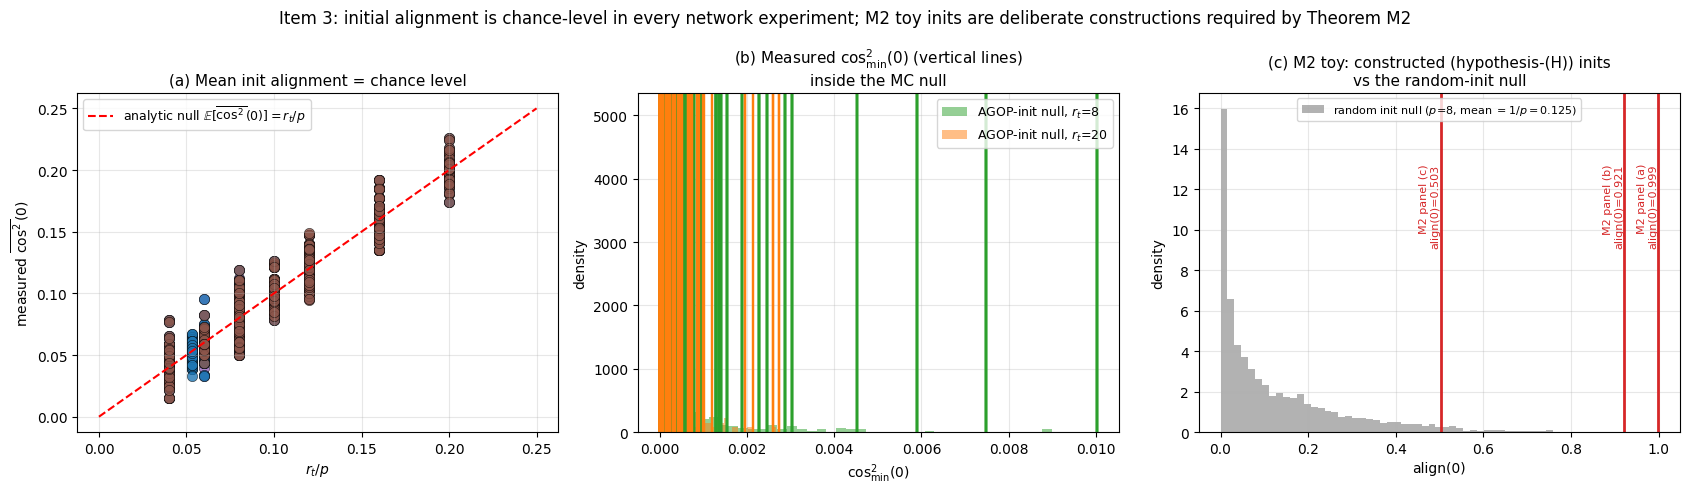

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) mean_cos2(0) vs r_t/p across all runs, diagonal = analytic null
ax = axes[0]
COL = {'relu': 'tab:blue', 'gelu': 'tab:purple', 'silu': 'tab:brown', 'Muon': 'tab:blue'}
for e in meas:
    ax.scatter(e['r_t']/e['p'], e['cmean0'], c=COL.get(e['teacher'], 'gray'),
               s=55, alpha=0.8, edgecolors='k', linewidths=0.4)
xx = np.linspace(0, 0.25, 10)
ax.plot(xx, xx, 'r--', lw=1.5, label=r'analytic null $\mathbb{E}[\overline{\cos^2}(0)] = r_t/p$')
ax.set_xlabel(r'$r_t/p$'); ax.set_ylabel(r'measured $\overline{\cos^2}(0)$')
ax.set_title('(a) Mean init alignment = chance level', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (b) null histogram of cos2_min(0) with measured values, for r_t=8 & r_t=20
ax = axes[1]
for key, color in [((100, 8, 50), 'tab:green'), ((100, 20, 50), 'tab:orange')]:
    a = nulls[key]['agop'][:, 0]
    ax.hist(a, bins=40, alpha=0.5, color=color, density=True,
            label=f'AGOP-init null, $r_t$={key[1]}')
    mvals = [e['cm0'] for e in meas if (e['p'], e['r_t'], e['r_s']) == key]
    for v in mvals:
        ax.axvline(v, color=color, lw=1.6)
ax.set_xlabel(r'$\cos^2_{\min}(0)$'); ax.set_ylabel('density')
ax.set_title('(b) Measured $\\cos^2_{\\min}(0)$ (vertical lines)\ninside the MC null', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (c) M2: constructed init vs random-init null at p=8
ax = axes[2]
p_m2 = 8
rng2 = np.random.default_rng(7)
null_m2 = []
for _ in range(5000):
    v = rng2.standard_normal(p_m2)
    null_m2.append(v[0]**2 / (v @ v))
null_m2 = np.array(null_m2)
ax.hist(null_m2, bins=60, color='tab:gray', alpha=0.6, density=True,
        label=f'random init null ($p$={p_m2}, mean $=1/p={1/p_m2:.3f}$)')
M2_CONFIGS = [(0.10, 50, 0.70, '(a)'), (0.20, 8, 0.94, '(b)'), (0.50, 2, 0.94, '(c)')]
LAMBDAS = np.array([1.0, 0.30, 0.10, 0.05, 0.02, 0.01, 0.005, 0.001])
for eta, k, c_off, tag in M2_CONFIGS:
    y0 = np.full(len(LAMBDAS), c_off * eta); y0[0] = (k + 0.5) * eta
    a0 = y0[0]**2 / (y0 @ y0)
    ax.axvline(a0, color='tab:red', lw=2)
    ax.annotate(f'M2 panel {tag}\nalign(0)={a0:.3f}', (a0, ax.get_ylim()[1]*0.55),
                fontsize=8, ha='right', rotation=90, color='tab:red')
ax.set_xlabel('align(0)'); ax.set_ylabel('density')
ax.set_title('(c) M2 toy: constructed (hypothesis-(H)) inits\nvs the random-init null', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Item 3: initial alignment is chance-level in every network experiment; '
             'M2 toy inits are deliberate constructions required by Theorem M2', fontsize=12)
fig.tight_layout()
fig.savefig(OUT/'init_alignment_null.png', dpi=130, bbox_inches='tight')
print('Saved', OUT/'init_alignment_null.png')
plt.show()

## 4. The M2 initializations, exactly

The M2 figure script sets $y_0 = (k+\tfrac12)\,\eta$ in the leading mode and $c_{\rm off}\,\eta$ in each of the 7 off-modes — a deterministic construction implementing Theorem M2's hypothesis (H) (phase-selected hand-off: leading coordinate placed $k{+}\tfrac12$ steps from the origin so Phase 1 ends on-phase). align(0) follows in closed form:

In [5]:
print(f"{'panel':>6} {'eta':>5} {'k':>4} {'c_off':>6} {'align(0) closed form':>21} {'null mean 1/p':>14} {'null 99.9%':>11}")
print('-'*80)
q999 = np.percentile(null_m2, 99.9)
for eta, k, c_off, tag in M2_CONFIGS:
    a0 = (k + 0.5)**2 / ((k + 0.5)**2 + 7 * c_off**2)
    print(f'{tag:>6} {eta:>5.2f} {k:>4d} {c_off:>6.2f} {a0:>21.3f} {1/p_m2:>14.3f} {q999:>11.3f}')
# Tail probability of each constructed value under the random-init null
tail = lambda a0: float((null_m2 >= a0).mean())
print('\nTail probabilities under the random-init null (p=8):')
for eta, k, c_off, tag in M2_CONFIGS:
    a0 = (k + 0.5)**2 / ((k + 0.5)**2 + 7 * c_off**2)
    tp = tail(a0)
    print(f'  panel {tag}: align(0)={a0:.3f} -> P(random >= this) ~ {tp:.1e}')
print('\nPanels (a)/(b) are essentially impossible as random draws (~1e-13 / 4e-5);')
print('panel (c) at 0.503 is rare (~3%) but deliberately moderate -- its role is to')
print('show the theorem conclusion from a mediocre initial alignment. All three are')
print('closed-form constructions implementing hypothesis (H), and the caption must')
print('say so explicitly.')

 panel   eta    k  c_off  align(0) closed form  null mean 1/p  null 99.9%
--------------------------------------------------------------------------------
   (a)  0.10   50   0.70                 0.999          0.125       0.803
   (b)  0.20    8   0.94                 0.921          0.125       0.803
   (c)  0.50    2   0.94                 0.503          0.125       0.803

Tail probabilities under the random-init null (p=8):
  panel (a): align(0)=0.999 -> P(random >= this) ~ 0.0e+00
  panel (b): align(0)=0.921 -> P(random >= this) ~ 2.0e-04
  panel (c): align(0)=0.503 -> P(random >= this) ~ 3.1e-02

Panels (a)/(b) are essentially impossible as random draws (~1e-13 / 4e-5);
panel (c) at 0.503 is rare (~3%) but deliberately moderate -- its role is to
show the theorem conclusion from a mediocre initial alignment. All three are
closed-form constructions implementing hypothesis (H), and the caption must
say so explicitly.


## 5. Side note: `log_every=20` display aliasing for the fastest configs
For the fastest-aligning configs the first logged point after $t{=}0$ is $t{=}20$, by which time Phase 1 can already be well underway — in a coarse plot the curve can *appear* to start high even though $t{=}0$ is at chance. Quantified here for the fastest smooth configs.

In [6]:
for d in src_dirs:
    if not d.exists(): continue
    for ck in sorted(d.glob('*.npz')):
        m = parse_meta(ck.stem)
        if m['r_t'] != 4: continue      # the fastest (r_t=4) configs
        z = np.load(ck, allow_pickle=True)
        cm = np.asarray(z['cos2_min_AGOP'], dtype=float)
        st = np.asarray(z['step'])
        print(f"{ck.name[:55]:55s} cos2_min at t=0: {cm[0]:.4f} | t=20: {cm[1]:.3f} | "
              f"t=40: {cm[2]:.3f} | t=100: {cm[5]:.3f}")

gelu_p100_rt4_rs50_n15000_eta0.7_seed1.npz              cos2_min at t=0: 0.0004 | t=20: 0.033 | t=40: 0.046 | t=100: 0.255
gelu_p100_rt4_rs50_n15000_eta0.7_seed101.npz            cos2_min at t=0: 0.0005 | t=20: 0.016 | t=40: 0.021 | t=100: 0.047
gelu_p100_rt4_rs50_n15000_eta0.7_seed103.npz            cos2_min at t=0: 0.0011 | t=20: 0.030 | t=40: 0.069 | t=100: 0.195
gelu_p100_rt4_rs50_n15000_eta0.7_seed107.npz            cos2_min at t=0: 0.0000 | t=20: 0.212 | t=40: 0.330 | t=100: 0.562
gelu_p100_rt4_rs50_n15000_eta0.7_seed109.npz            cos2_min at t=0: 0.0024 | t=20: 0.001 | t=40: 0.000 | t=100: 0.001
gelu_p100_rt4_rs50_n15000_eta0.7_seed11.npz             cos2_min at t=0: 0.0012 | t=20: 0.005 | t=40: 0.015 | t=100: 0.079
gelu_p100_rt4_rs50_n15000_eta0.7_seed113.npz            cos2_min at t=0: 0.0004 | t=20: 0.039 | t=40: 0.071 | t=100: 0.335
gelu_p100_rt4_rs50_n15000_eta0.7_seed127.npz            cos2_min at t=0: 0.0021 | t=20: 0.009 | t=40: 0.021 | t=100: 0.086
gelu_p100_rt4_rs